# EDA 01 · Analiza Zbioru Respiratory Sound Database ICBHI 2017

<div style="background-color: #f8f9fa; border-left: 4px solid #2b6cb0; padding: 12px 16px; margin-bottom: 20px; border-radius: 0 4px 4px 0;">
  <strong>Praca Inżynierska:</strong> -- <br>
  <strong>Autorzy:</strong> Norbert Gwiazda, Mateusz Ciurzyński | <strong>Data:</strong> 2026-09-02<br>
  <strong>Zbiór danych:</strong> Respiratory Sound Database (ICBHI 2017)<br>
  <strong>Cel:</strong> --
</div>

---

## Spis treści
- [1. Kontekst i Charakterystyka Bazy Danych](#1-kontekst-i-charakterystyka-bazy-danych)
- [2. Środowisko i Import Bibliotek](#2-środowisko-i-import-bibliotek)
- [3. Wczytanie danych](#3-wczytanie-danych)
- [4. Analiza kategoryczna](#4-analiza-kategoryczna)
  - [4.1 Typy cyklów oddechowych](#41-typy-cyklów-oddechowych)

---

## 1. Kontekst i Charakterystyka Bazy Danych

Zbiór *Respiratory Sound Database* zawiera próbki cykli oddechowych, zebranych niezależnie przez dwa zespoły naukowe z Portugalii i Grecji na przestrzeni kilku: 
- **Zespół portugalski:** *School of Health Sciences* na Uniwersytecie w Aveiro (ESSUA) - nagrania w Laboratorium Badań i Rehabilitacji Oddechowej (**Lab3R**) oraz w Szpitalu Infante D. Pedro w Aveiro.
- **Zespół grecki:** *Arystotelesowski Uniwersytet w Tesalonikach* (AUTH) oraz *Uniwersytet w Coimbrze* (UC) — nagrania w Szpitalu Głównym Papanikolaou w Tesalonikach oraz w Szpitalu Ogólnym w Imathia.

Baza danych zawiera ponad $5,5$ godzin nagrań, zawierających około $6898$ cykli oddechowych. Dane zebrano od $126$ pacjentów. Nazwy plików z nagraniami zawierają metadane określające indeks pacjenta, miejsce badania, sprzęt użyty do badania oraz sposób badania. Dodatkowo zbiór zawiera pliki tekstowe odpowiadające nagraniom określające czy i w którym momencie nagrania występują świsty lub trzaski.

Lokalizacje osłuchu:
- Trachea (Tc) - Tchawica
- Anterior left (Al) - Przód lewy (przednia lewa strona klatki piersiowej)
- Anterior right (Ar) - Przód prawy (przednia prawa strona klatki piersiowej)
- Posterior left (Pl) - Tył lewy (tylna lewa strona klatki piersiowej)
- Posterior right (Pr) - Tył prawy (tylna prawa strona klatki piersiowej)
- Lateral left (Ll) - Bok lewy (boczna lewa strona klatki piersiowej)
- Lateral right (Lr) - Bok prawy (boczna prawa strona klatki piersiowej)

Sprzęt użyty do badania:
- AKG C417L Microphone (AKGC417L), 
- 3M Littmann Classic II SE Stethoscope (LittC2SE), 
- 3M Litmmann 3200 Electronic Stethoscope (Litt3200), 
- WelchAllyn Meditron Master Elite Electronic Stethoscope (Meditron)

Dostępny jest również plik `ICBHI_Challenge_diagnosis.txt` zawierający diagnozę choroby dla każdego pacjenta. Możliwe diagnozy to:
- Zdrowy
- Astma
- Przewlekła Obturacyjna Choroba Płuc (COPD)
- Zakażenie górnych dróg oddechowych (URTI)
- Infekcja dolnych dróg oddechowych (LRTI)
- Rozstrzenie oskrzeli (Bronchiectasis)
- Pneumonia
- Zapalenie oskrzelików (Bronchiolitis)


## 2. Środowisko i Import Bibliotek

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.close_figures = True


import os
import warnings
from pathlib import Path

# Wizualizacja danych
import matplotlib.pyplot as plt

# Przetwarzanie i analiza numeryczna
import numpy as np
import pandas as pd
import seaborn as sns
from pyfonts import load_google_font
from pypalettes import load_cmap, load_palette

# Wyciszenie zbędnych ostrzeżeń
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

# Wczytanie czionek i palet kolorów
dark_two = load_palette("Dark2")
regular = load_google_font("Roboto", weight=400)
medium = load_google_font("Roboto", weight=500)
bold = load_google_font("Roboto", weight=700)
heavy = load_google_font("Roboto", weight=800)

# Ustawienie motywu
sns.set_theme(style="whitegrid")


## 3. Wczytanie danych

W pierwszej kolejności przyjrzymy się zawartości folderu zbioru danych

In [110]:
DATA_PATH = Path('../data/ICBHI_final_database/')
DIAGNOSIS_FILE = DATA_PATH / 'ICBHI_Challenge_diagnosis.txt'

audio_files = list(DATA_PATH.rglob("*.wav"))

print(f"Wszystkich nagrań: {len(audio_files)}")
print("Pierwsze 5 nagrań:")
for f in audio_files[:5]:
    print(f"  - {f.relative_to(DATA_PATH)}")

print("\n\nZawartość pliku metadanych:")
print(*DIAGNOSIS_FILE.read_text().splitlines()[:5], sep="\n")


Wszystkich nagrań: 920
Pierwsze 5 nagrań:
  - 163_2b2_Ll_mc_AKGC417L.wav
  - 139_1b1_Pr_sc_Litt3200.wav
  - 157_1b1_Al_sc_Meditron.wav
  - 138_2p2_Lr_mc_AKGC417L.wav
  - 177_2b4_Tc_mc_AKGC417L.wav


Zawartość pliku metadanych:
101	URTI
102	Healthy
103	Asthma
104	COPD
105	URTI


Przetworzenie plików audio może być problematyczne, dlatego załadujemy metadane do ramki pandas, a do samych plików audio umieścimy wskaźnik.

In [111]:
annotations = []
file_metadata = []

for file in DATA_PATH.iterdir():
    parts = file.stem.split("_")
    if len(parts) != 5:
        continue

    if file.suffix == ".wav":
        file_metadata.append({"patient_id": int(parts[0]),
                              "recording_id": parts[1],
                              "chest_location": parts[2],
                              "acquisition_mode": parts[3],
                              "recording_equipment": parts[4],
                              "filename": file.stem})
    elif file.suffix == ".txt":
        try:
            anno_df = pd.read_csv(
                file, sep="\t", names=["start", "end", "crackles", "wheezes"]
            )
            anno_df["filename"] = file.stem
            if anno_df is not None:
                annotations.append(anno_df)
        except Exception as e:
            print(f"Pominięto uszkodzony plik adnotacji {file.name}: {e}")

df = pd.concat(annotations, ignore_index=True)
metadata_df = pd.DataFrame(file_metadata)
patients_df = pd.read_csv(
    DIAGNOSIS_FILE, sep="\t", names=["patient_id", "diagnosis"]
)
merged_metadata = pd.merge(
    metadata_df, patients_df, on="patient_id", how="left"
)
df = pd.merge(df, merged_metadata, on="filename", how="left")

df.head()

,start,end,crackles,wheezes,filename,patient_id,recording_id,chest_location,acquisition_mode,recording_equipment,diagnosis
0,1.144,3.848,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
1,3.848,6.786,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
2,6.786,9.240,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
3,9.240,11.962,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD
4,11.962,14.716,0,0,172_1b3_Al_mc_AKGC417L,172,1b3,Al,mc,AKGC417L,COPD


In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   start                6898 non-null   float64
 1   end                  6898 non-null   float64
 2   crackles             6898 non-null   int64  
 3   wheezes              6898 non-null   int64  
 4   filename             6898 non-null   str    
 5   patient_id           6898 non-null   int64  
 6   recording_id         6898 non-null   str    
 7   chest_location       6898 non-null   str    
 8   acquisition_mode     6898 non-null   str    
 9   recording_equipment  6898 non-null   str    
 10  diagnosis            6898 non-null   str    
dtypes: float64(2), int64(3), str(6)
memory usage: 592.9 KB


## 4. Analiza cech kategorycznych

Przygotowany zbiór danych poddamy teraz analizie, zaczynając od analizy kategorii. W ramach niej, przeanalizowana zostanie każda ze zmiennych kategorycznych. Po każdej podsekcji nastąpi zbiorcze podsumowanie wyników badań.

---


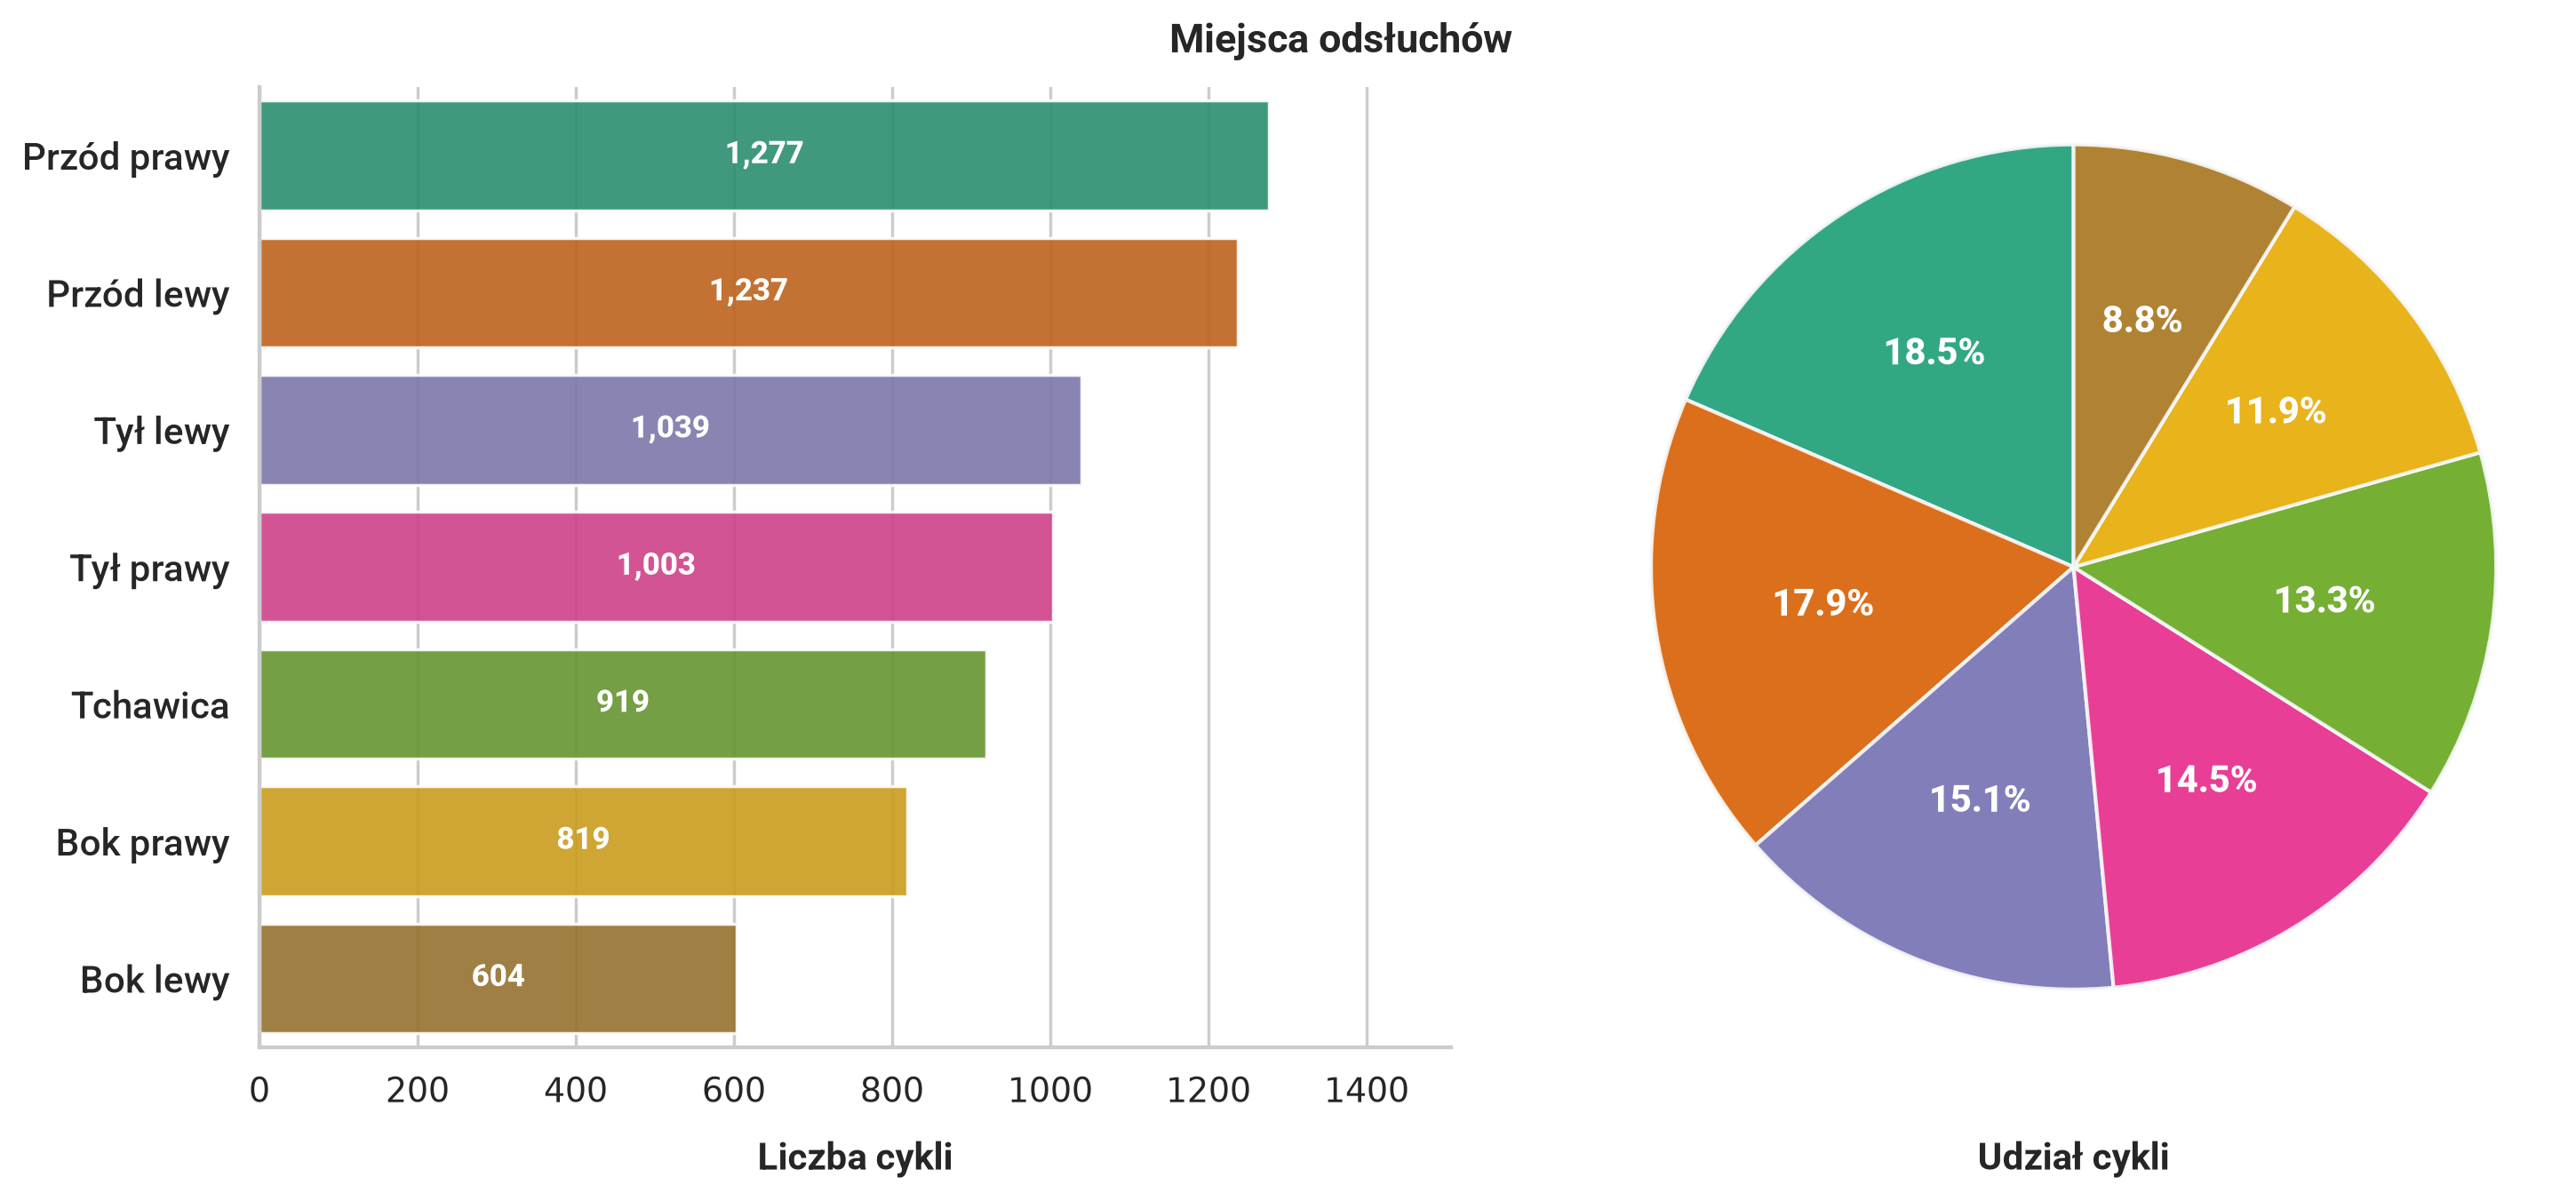

In [113]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['chest_location'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:7], strict=True))
labels_map = {
    "Ar": "Przód prawy",
    "Al": "Przód lewy",
    "Tc": "Tchawica",
    "Pl": "Tył lewy",
    "Pr": "Tył prawy",
    "Ll": "Bok lewy",
    "Lr": "Bok prawy"
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['chest_location'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Miejsca odsłuchów ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [114]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Typy cykli': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Typy cykli,Liczebność,Udział (%)
0,Przód prawy,"1,277",18.51%
1,Przód lewy,"1,237",17.93%
2,Tył lewy,"1,039",15.06%
3,Tył prawy,"1,003",14.54%
4,Tchawica,919,13.32%
5,Bok prawy,819,11.87%
6,Bok lewy,604,8.76%


#TODO

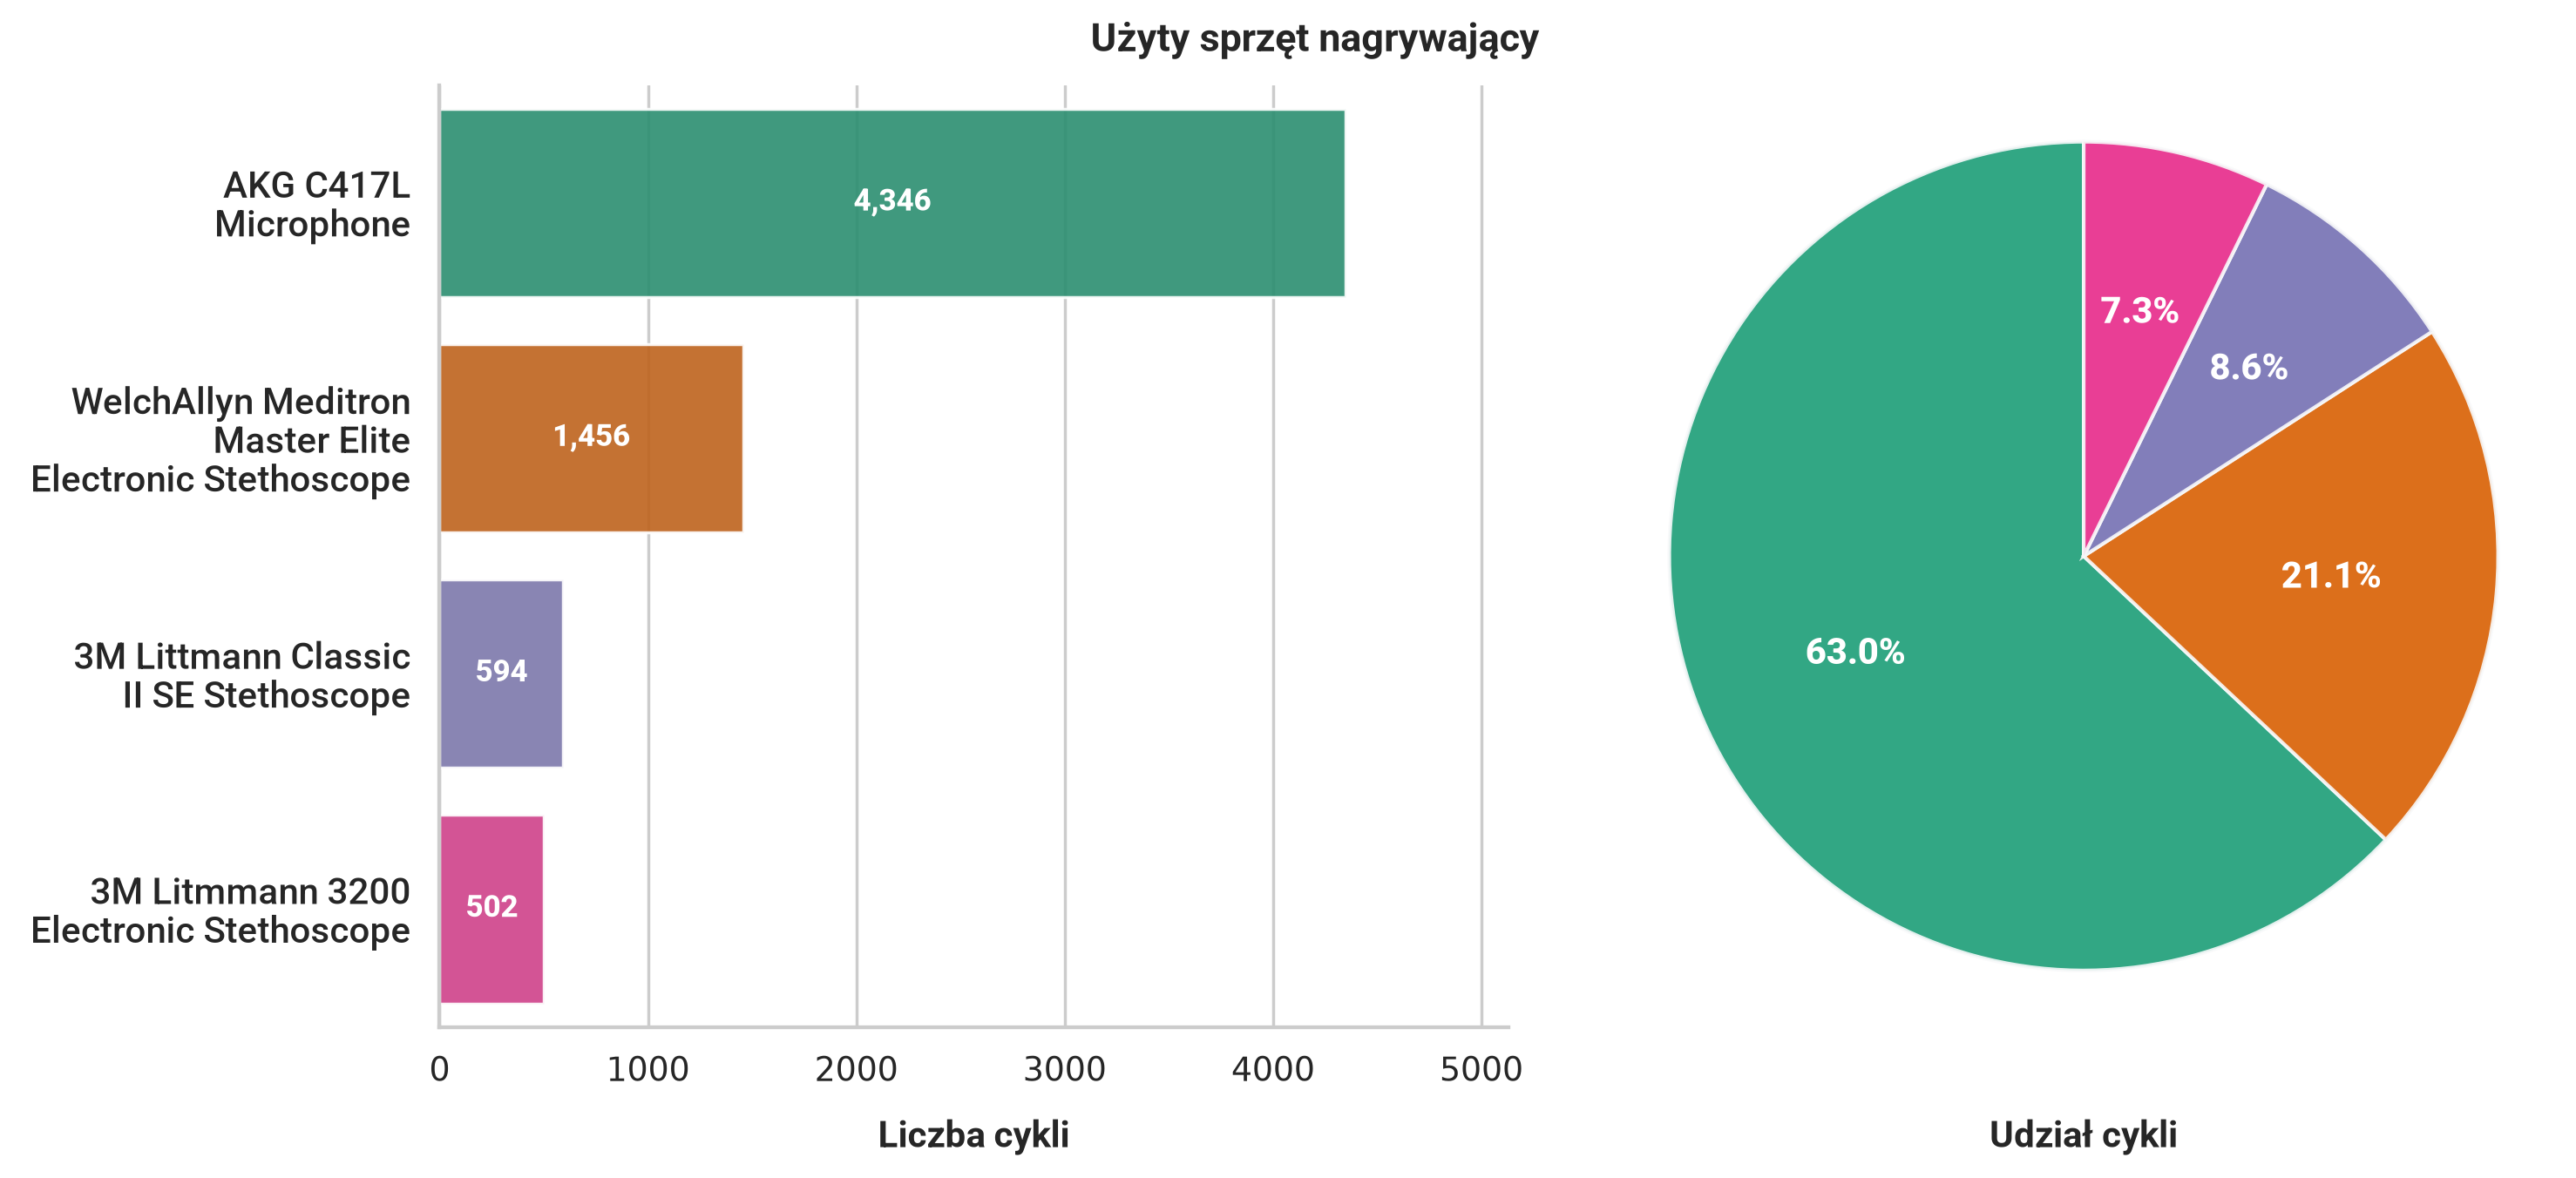

In [115]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['recording_equipment'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:4], strict=True))
labels_map = {
    "AKGC417L": "AKG C417L\n Microphone",
    "LittC2SE": "3M Littmann Classic\n II SE Stethoscope",
    "Litt3200": "3M Litmmann 3200\n Electronic Stethoscope",
    "Meditron": "WelchAllyn Meditron\n Master Elite\n Electronic Stethoscope"
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Podmienione etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['recording_equipment'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Użyty sprzęt nagrywający ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [116]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Typy cykli': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Typy cykli,Liczebność,Udział (%)
0,AKG C417L\n Microphone,"4,346",63.00%
1,WelchAllyn Meditron\n Master Elite\n Electroni...,"1,456",21.11%
2,3M Littmann Classic\n II SE Stethoscope,594,8.61%
3,3M Litmmann 3200\n Electronic Stethoscope,502,7.28%


#TODO


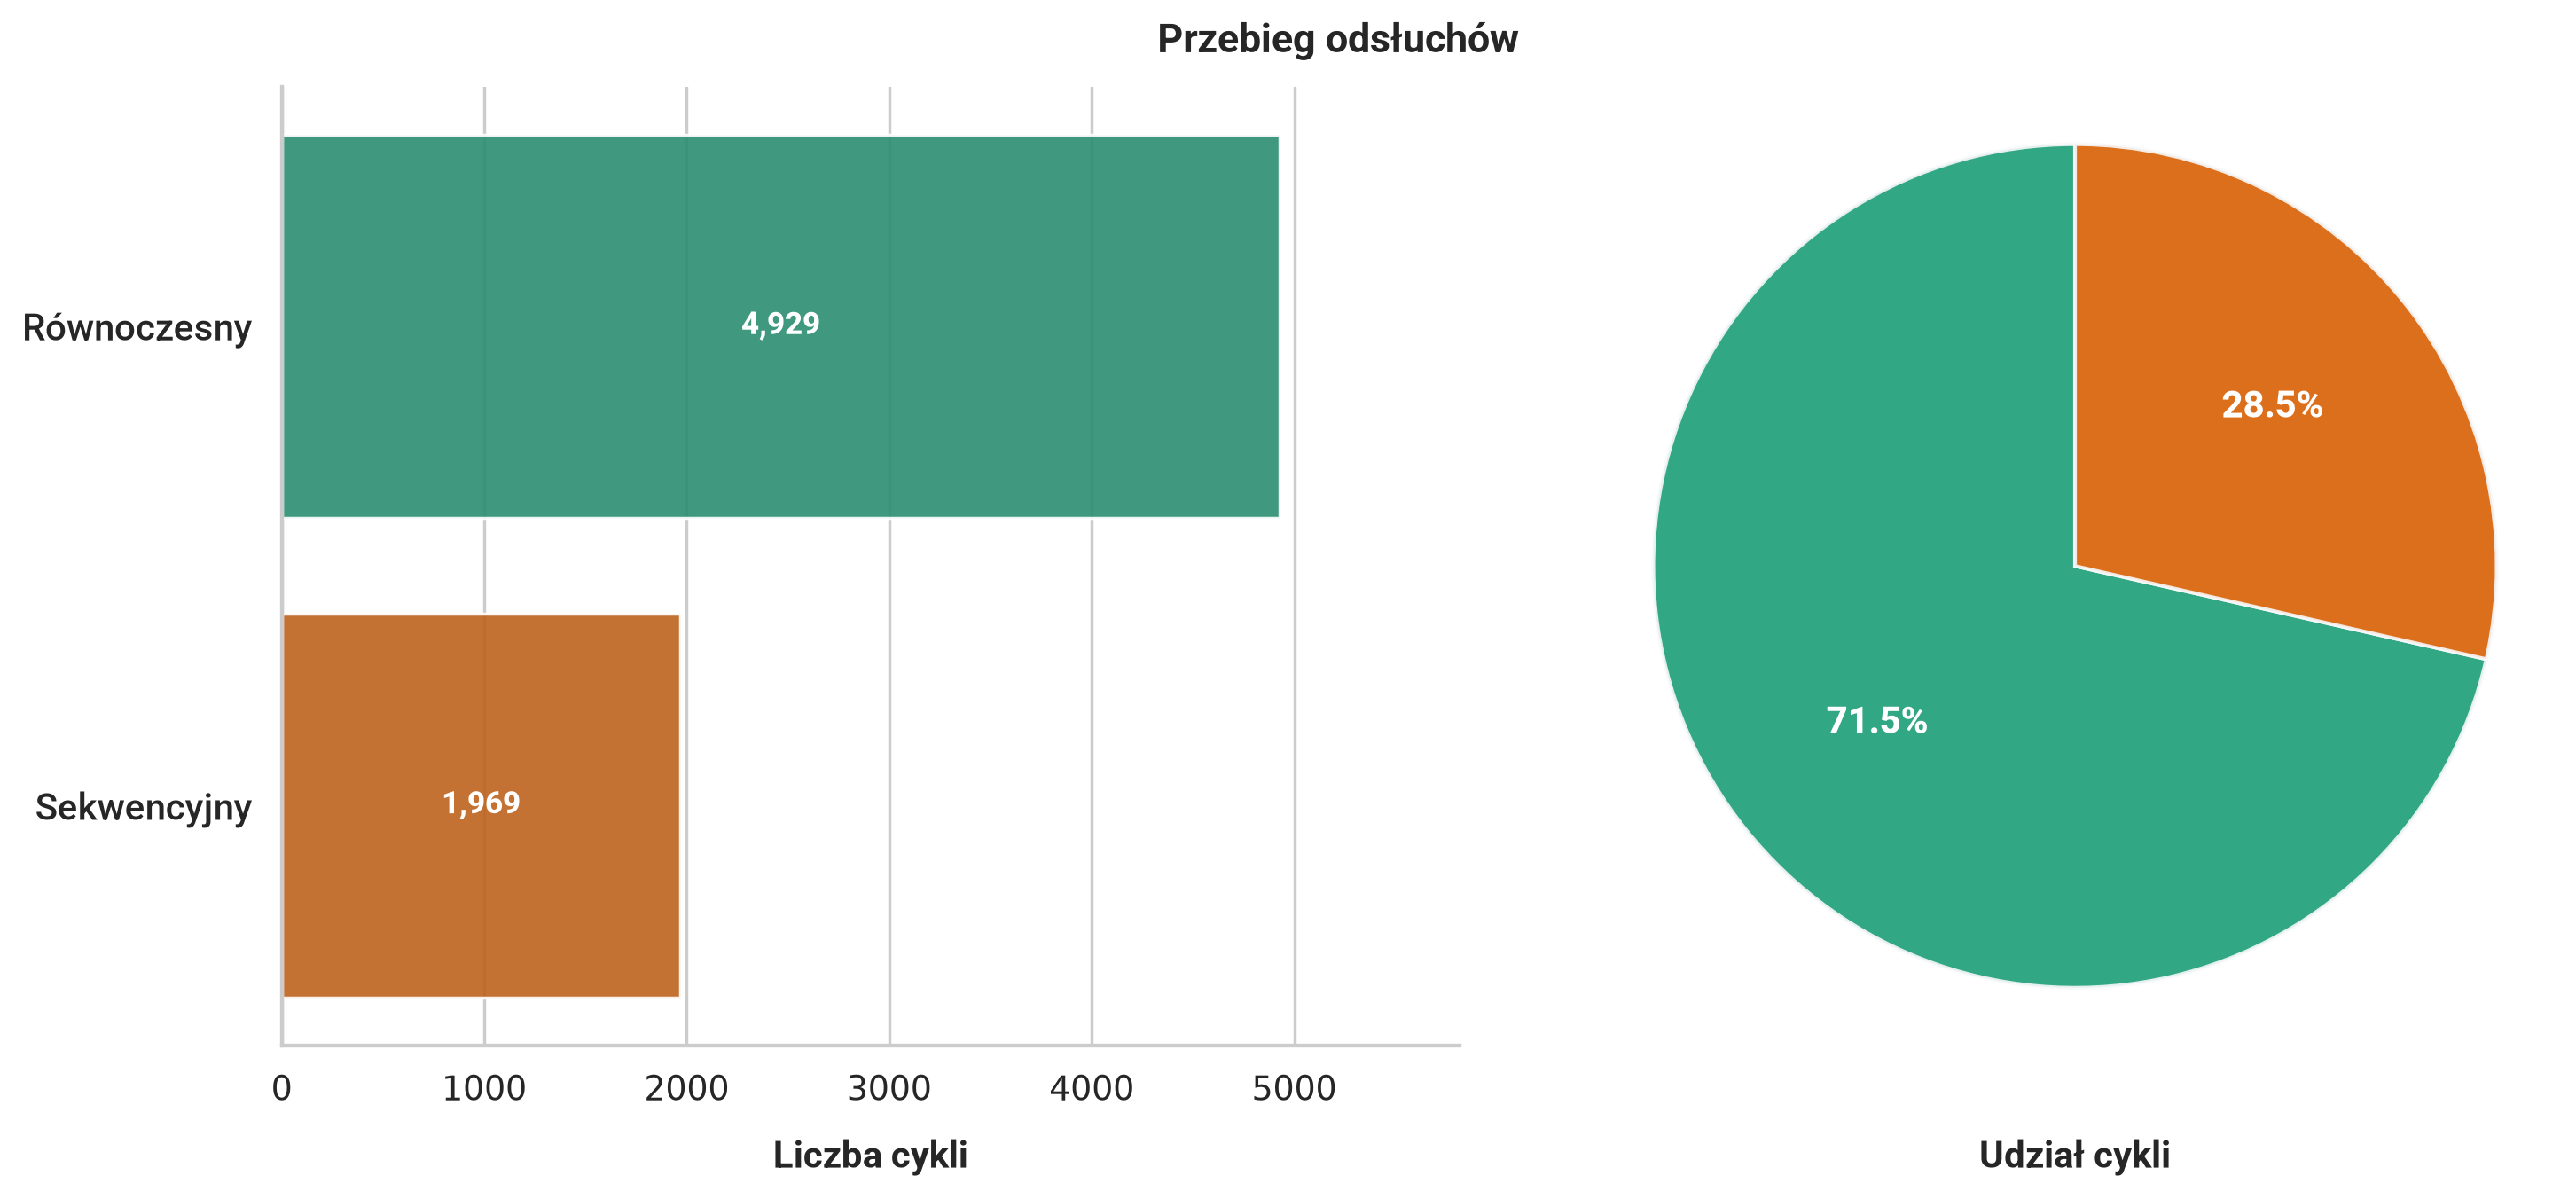

In [117]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['acquisition_mode'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:2], strict=True))
labels_map = {
    "mc": "Równoczesny",
    "sc": "Sekwencyjny",
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="white", label_type="center")

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['acquisition_mode'].value_counts().max() * 1.18)

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=[color_dict[cat] for cat in counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Przebieg odsłuchów ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [118]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Typy cykli': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Typy cykli,Liczebność,Udział (%)
0,Równoczesny,"4,929",71.46%
1,Sekwencyjny,"1,969",28.54%


#TODO

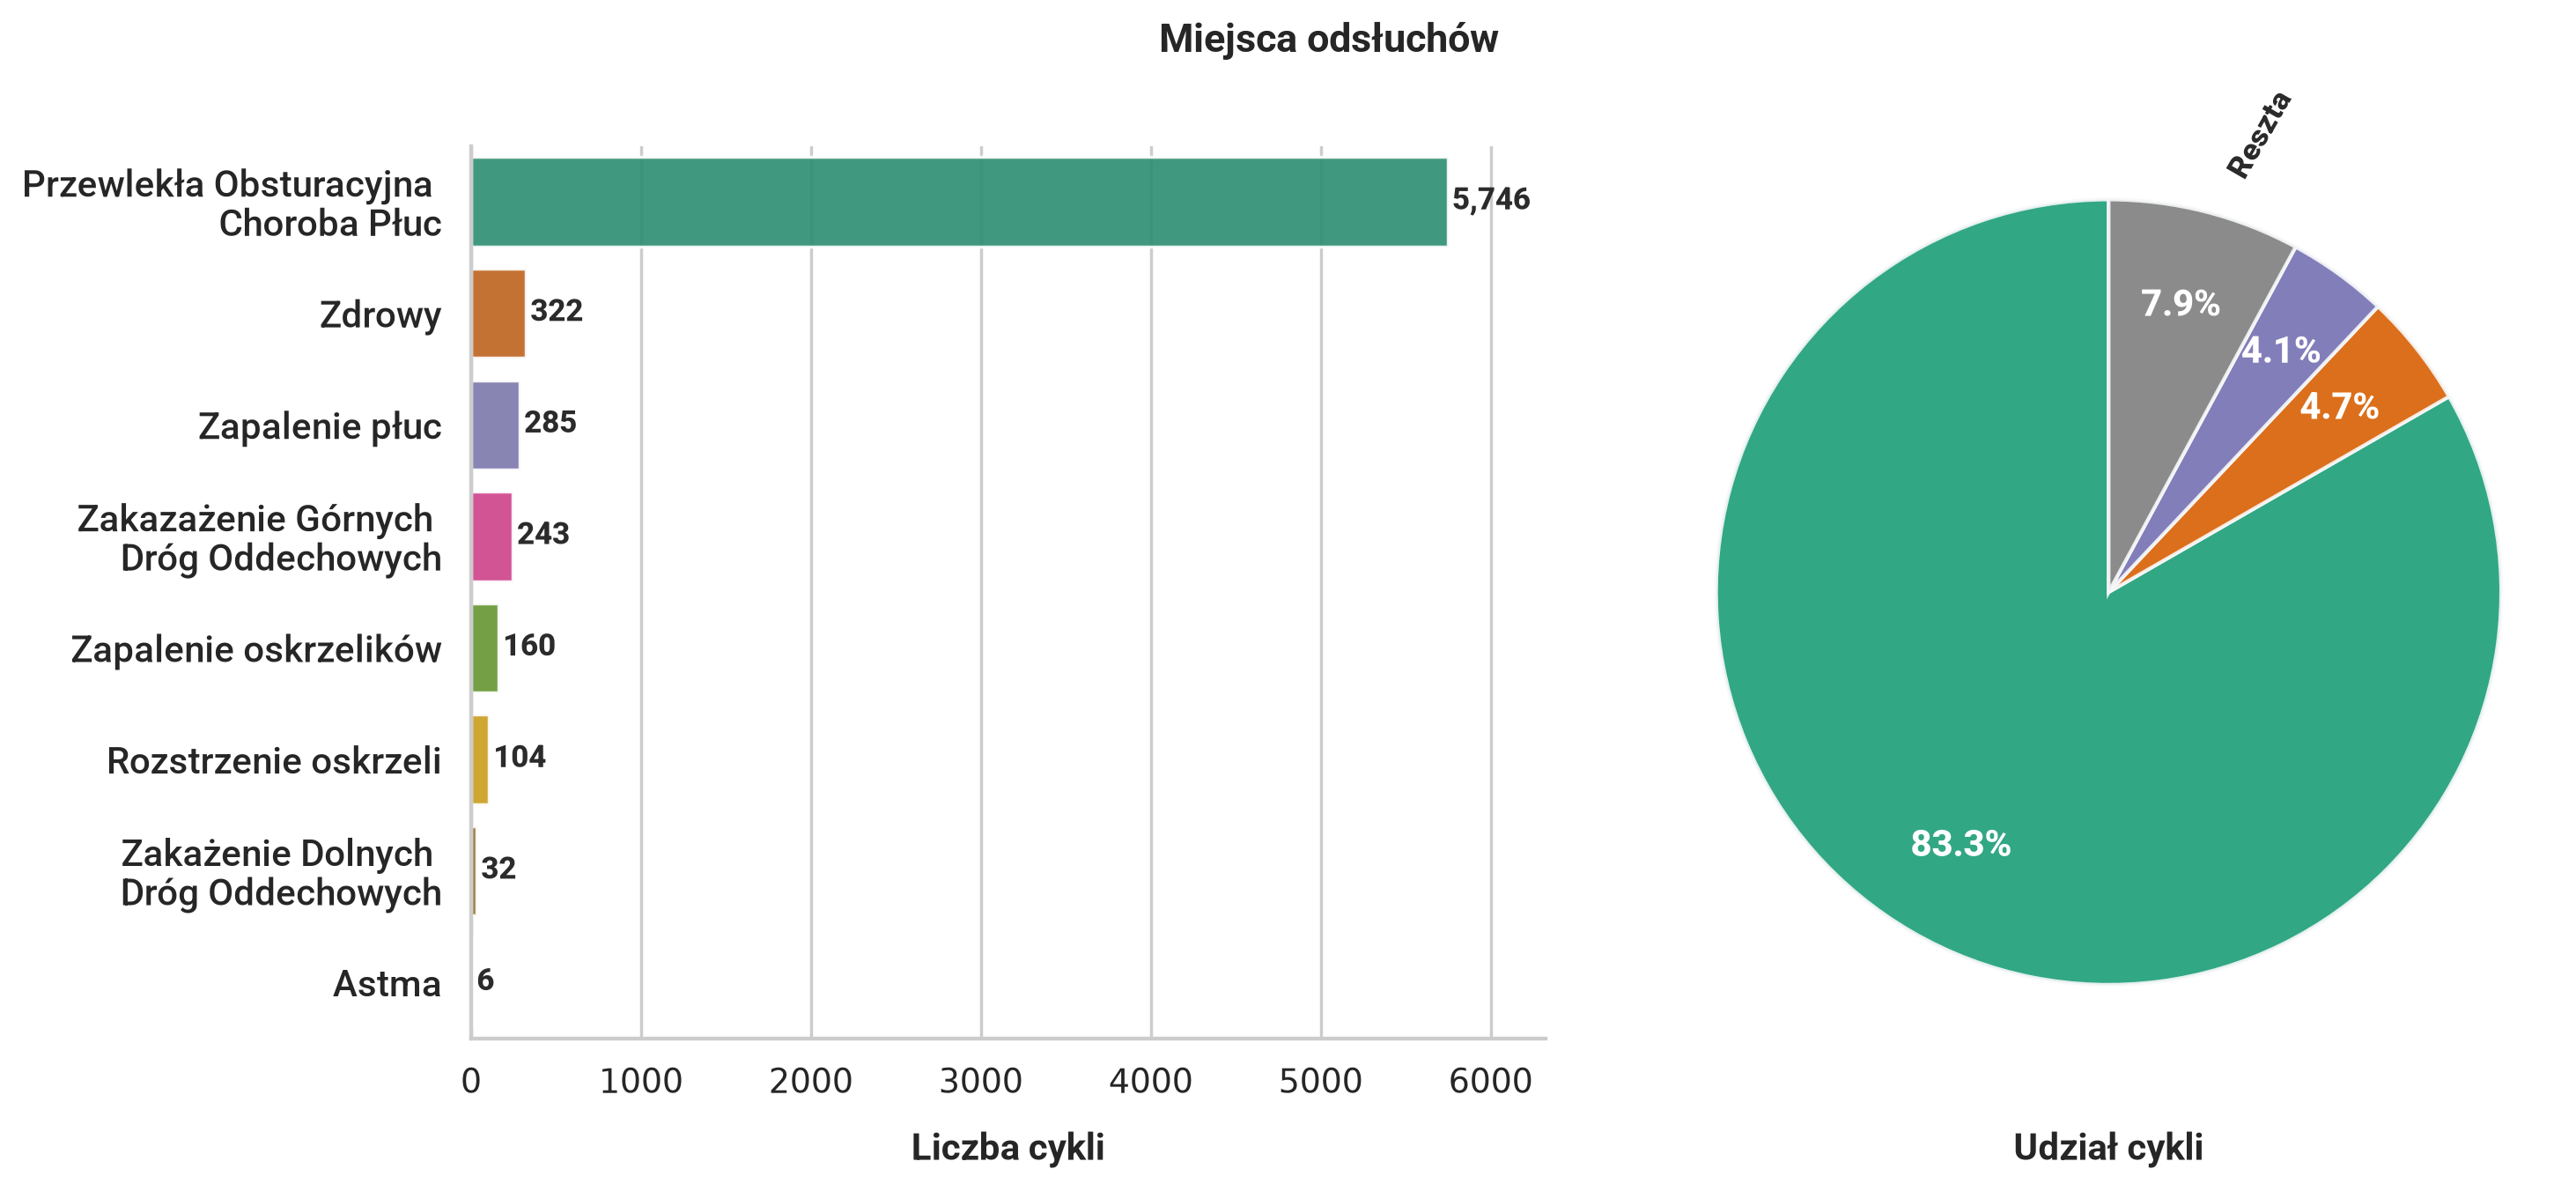

In [119]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=125, constrained_layout=True)

# Chcemy, aby kolory były przypisane do kategorii
counts = df['diagnosis'].value_counts().sort_values(ascending=False)
color_dict = dict(zip(counts.index, dark_two[:8], strict=True))
labels_map = {
    'COPD': 'Przewlekła Obsturacyjna \nChoroba Płuc',
    'Bronchiectasis': 'Rozstrzenie oskrzeli',
    'Healthy': 'Zdrowy',
    'URTI': 'Zakazażenie Górnych \nDróg Oddechowych',
    'LRTI': 'Zakażenie Dolnych \nDróg Oddechowych',
    'Bronchiolitis': 'Zapalenie oskrzelików',
    'Pneumonia': 'Zapalenie płuc',
    'Asthma': 'Astma'
}

# Wykres słupkowy do oceny ilości
sns.barplot(
    y=counts.index,
    x=counts.values,
    hue=counts.index,
    palette=color_dict,
    legend=False,
    ax=ax1,
    alpha=0.9
)

# Polskie etykiety
ax1.set_yticks(range(len(labels_map)))
ax1.set_yticklabels([labels_map[label] for label in counts.index], fontsize=10.5, font=medium)

# Wartości liczbowe przy słupkach
for container in ax1.containers:
    labels = [f"{v.get_width():,.0f}" for v in container]
    ax1.bar_label(container, labels=labels, size=10, font=heavy, color="#2b2b2b", label_type="edge", padding=1.5)

# Poprawione etykiety
ax1.set_ylabel("")
ax1.set_xlabel('Liczba cykli', labelpad=10, font=bold)
ax1.set_xlim(0, df['diagnosis'].value_counts().max() * 1.1)

# Aby zapobiec nagromadzeniu trudnych do odczytania pasków, zgrupujemy małe wartosci w "Reszta"
top_3 = counts.iloc[:3]
others_sum = counts.iloc[3:].sum()
pie_counts = pd.concat([top_3, pd.Series({'Reszta': others_sum})])
pie_color_dict = color_dict.copy()
pie_color_dict['Reszta'] = '#7F7F7F'

# Podpisujemy resztę, aby wykres był zrozumiały
custom_labels = [cat if cat == 'Reszta' else '' for cat in pie_counts.index]

# Wykres kołowy do prezentacji udziału w całości
wedges, texts, autotexts = ax2.pie(
    pie_counts,
    labels=custom_labels,
    labeldistance=1.2,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    colors=[pie_color_dict[cat] for cat in pie_counts.index],
    wedgeprops={"alpha":0.9, "linewidth": 1.2, "edgecolor": "#f8f9fa"},
    radius=1.1
)

# Modyfikacja wyglądu i obrotu etykiety 'Reszta'
for text in texts:
    if text.get_text():
        text.set_rotation(60)
        text.set_font(heavy)
        text.set_fontsize(10)
        text.set_color('#2b2b2b')

# Korekta graficzna wartości procentowych
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(10)
    autotext.set_font(heavy)

ax2.set_xlabel('Udział cykli', labelpad=10, font=bold)

fig.align_xlabels([ax1,ax2])
fig.suptitle('Miejsca odsłuchów ', size=13, font=bold, y=1.05)

sns.despine(top=True, right=True)
plt.show()

In [120]:
percentages = (counts / len(df)) * 100
pd.DataFrame({'Typy cykli': [labels_map[label] for label in counts.index], 'Liczebność': [f"{val:,.0f}" for val in counts], 'Udział (%)': [f"{val:.2f}%" for val in percentages]})

,Typy cykli,Liczebność,Udział (%)
0,Przewlekła Obsturacyjna \nChoroba Płuc,"5,746",83.30%
1,Zdrowy,322,4.67%
2,Zapalenie płuc,285,4.13%
3,Zakazażenie Górnych \nDróg Oddechowych,243,3.52%
4,Zapalenie oskrzelików,160,2.32%
5,Rozstrzenie oskrzeli,104,1.51%
6,Zakażenie Dolnych \nDróg Oddechowych,32,0.46%
7,Astma,6,0.09%


#TODO

## 5. Analiza cech binarnych

---

### 5.1 Trzeszczenia

#TODO